In [38]:
from pathlib import Path

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import xarray as xr
from IPython.display import clear_output, display
from tqdm import tqdm

## Weather Station/Era5 Temp residuals

In [2]:
DATA = Path("/home2/lobib/gen_hack/data/main")

In [3]:
gadm_filepath = DATA / "gadm_410_europe.gpkg"

In [4]:
gdf = gpd.read_file(gadm_filepath)

In [11]:
eca_tx_datafolder = DATA / "ECA_blend_tx/"
stations_filepath = eca_tx_datafolder / "stations.txt"

In [12]:
def dms_to_decimal(dms_str):
    # This function converts a DMS (Degrees:Minutes:Seconds) string to decimal degrees.
    dms_str = dms_str.strip()

    sign = 1 if dms_str[0] == "+" else -1

    dms_str = dms_str[1:]

    parts = dms_str.split(":")
    degrees = float(parts[0])
    minutes = float(parts[1])
    seconds = float(parts[2])

    decimal = sign * (degrees + minutes / 60 + seconds / 3600)

    return decimal

In [13]:
stations_df = pd.read_csv(stations_filepath, skiprows=17, skipinitialspace=True)

stations_df["LAT_decimal"] = stations_df["LAT"].apply(dms_to_decimal)
stations_df["LON_decimal"] = stations_df["LON"].apply(dms_to_decimal)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df["LON_decimal"], stations_df["LAT_decimal"]),
    crs="EPSG:4326",  # (WGS84, adequate for lat/lon coordinates)
).drop(columns=["LAT", "LON", "LAT_decimal", "LON_decimal"])

print(f"Number of registered stations: {len(stations_gdf)}")
stations_gdf.head()

Number of registered stations: 8568


,STAID,STANAME,CN,HGHT,geometry
0,1,VAEXJOE,SE,166,POINT (14.8 56.86667)
1,2,FALUN,SE,160,POINT (15.61667 60.61667)
2,3,STENSELE,SE,325,POINT (17.16639 65.06667)
3,4,LINKOEPING,SE,93,POINT (15.53306 58.4)
4,5,LINKOEPING-MALMSLAETT,SE,93,POINT (15.53306 58.4)


In [17]:
era5_files = sorted(
    DATA.glob("derived-era5-land-daily-statistics/*_2m_temperature_daily_maximum.nc")
)
era5_ds = xr.open_mfdataset(era5_files, combine="by_coords")
era5_ds["t2m_celsius"] = era5_ds["t2m"] - 273.15
era5_ds

<xarray.Dataset> Size: 4GB
Dimensions:      (valid_time: 2098, latitude: 350, longitude: 660)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 17kB 2020-01-01 ... 2025-09-28
  * latitude     (latitude) float64 3kB 69.9 69.8 69.7 69.6 ... 35.2 35.1 35.0
  * longitude    (longitude) float64 5kB -25.0 -24.9 -24.8 ... 40.7 40.8 40.9
    number       int64 8B 0
Data variables:
    t2m          (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(23, 22, 42), meta=np.ndarray>
    t2m_celsius  (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(23, 22, 42), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-03T16:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
all_lats = xr.DataArray(stations_gdf.geometry.y.values, dims="station")
all_lons = xr.DataArray(stations_gdf.geometry.x.values, dims="station")

era5_all_stations = (
    era5_ds["t2m_celsius"]
    .sel(latitude=all_lats, longitude=all_lons, method="nearest")
    .compute()
)  # shape: (time, n_stations) — loaded into memory once

In [24]:
all_residuals = []
era5_times = pd.DatetimeIndex(era5_ds.valid_time.values)

for i, (_, row) in tqdm(
    enumerate(stations_gdf.iterrows()), total=len(stations_gdf), colour="green"
):
    filepath = eca_tx_datafolder / f"TX_STAID{row['STAID']:06d}.txt"
    if not filepath.exists():
        continue

    station_df = pd.read_csv(filepath, skiprows=20, skipinitialspace=True)
    station_df = station_df[station_df["Q_TX"] == 0].copy()
    station_df["DATE"] = pd.to_datetime(station_df["DATE"], format="%Y%m%d")
    station_df = station_df[station_df["DATE"].isin(era5_times)]

    if len(station_df) == 0:
        continue

    station_df["TX_celsius"] = station_df["TX"] / 10.0

    # Look up ERA5 values by time index — no .sel(), just indexing
    time_indices = era5_times.get_indexer(station_df["DATE"])
    era5_vals = era5_all_stations.values[time_indices, i]

    all_residuals.append(
        pd.DataFrame(
            {
                "STAID": row["STAID"],
                "date": station_df["DATE"].values,
                "station_celsius": station_df["TX_celsius"].values,
                "era5_celsius": era5_vals,
                "residual": station_df["TX_celsius"].values - era5_vals,
            }
        )
    )

residuals_df = pd.concat(all_residuals, ignore_index=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8568/8568 [04:47<00:00, 29.79it/s]


/tmp/ipykernel_2321540/273645327.py:15: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



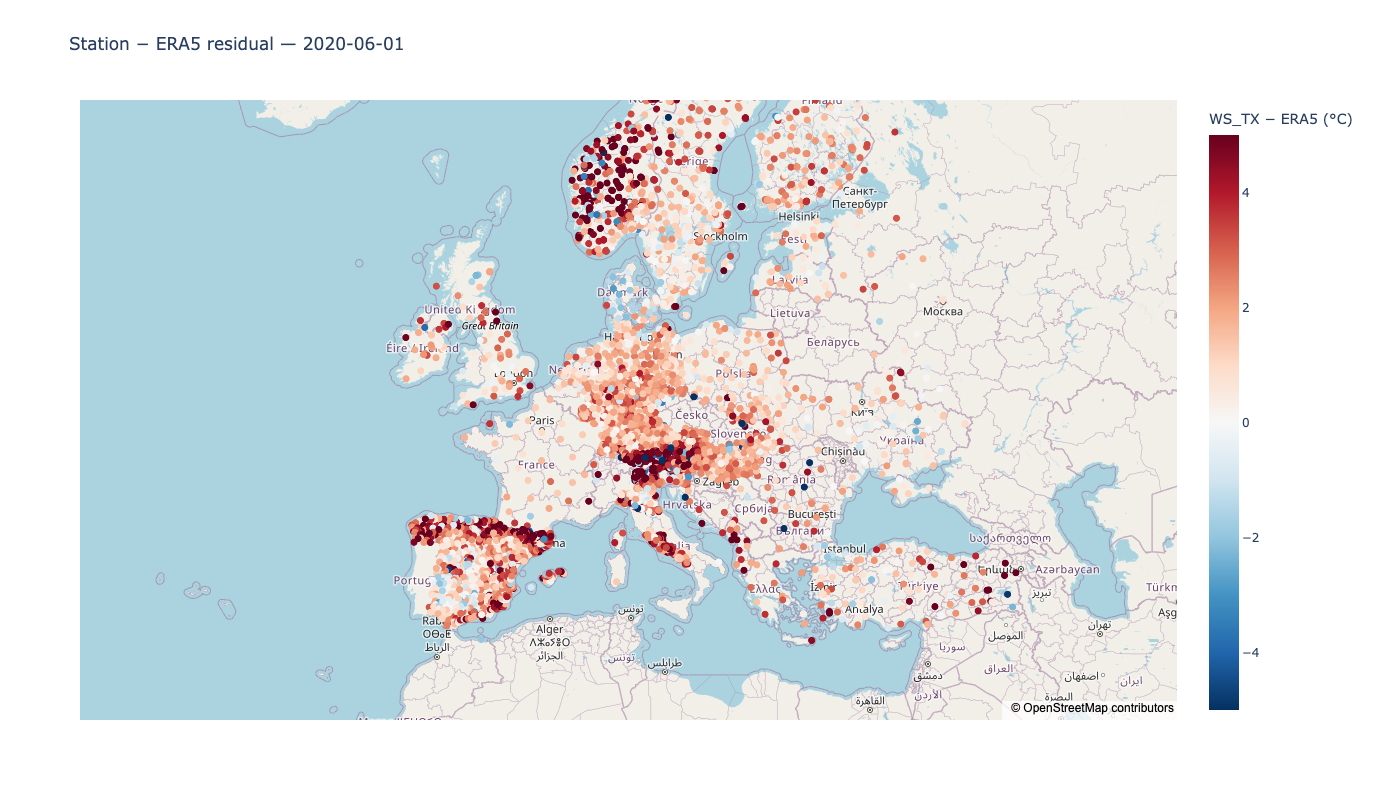

In [59]:
# Merge station coordinates
residuals_with_coords = residuals_df.merge(
    stations_gdf[["STAID"]].assign(
        lat=stations_gdf.geometry.y,
        lon=stations_gdf.geometry.x,
    ),
    on="STAID",
)

# Pick a day
day = "2020-06-01"
day_df = residuals_with_coords[residuals_with_coords["date"] == day]
day_df = day_df.dropna(subset=["residual"])

fig = px.scatter_mapbox(
    day_df,
    lat="lat",
    lon="lon",
    color="residual",
    color_continuous_scale="RdBu_r",
    range_color=[-5, 5],
    zoom=3,
    center={"lat": 50, "lon": 10},
    mapbox_style="open-street-map",
    hover_data=["STAID", "station_celsius", "era5_celsius", "residual"],
    title=f"Station − ERA5 residual — {day}",
)
fig.update_traces(marker=dict(size=8))
fig.update_layout(height=800, width=1200, coloraxis_colorbar_title="WS_TX − ERA5 (°C)")
fig.show()